# Explicabilidad del modelo de regresión logística con SHAP

En este notebook se lleva a cabo el análisis de explicabilidad del mejor modelo supervisado entrenado con las 25 palabras funcionales más frecuentes, el cual es un modelo de regresión logística obtenido como resultado del experimento ejecutado en el notebook `04_mfw_robustness_experiment.ipynb`. El objetivo es entender cómo las palabras funcionales influyen en las predicciones del modelo y cuáles de ellas son más relevantes para la variable objetivo.

Para ello, se utiliza la librería SHAP (SHapley Additive exPlanations), que permite descomponer la predicción de un modelo en la contribución de cada característica. En este caso, se interpreta SHAP sobre la salida lineal de la regresión logística para cada clase, lo que significa que un valor positivo empuja hacia el autor explicado y un valor negativo reduce la puntuación de ese autor.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from joblib import load
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from whodunit_stylometry.utils.plot_utils import (
    plot_confussion_matrix,
    plot_global_bar_for_author,
    plot_beeswarm_for_author,
    plot_shap_decision,
    plot_shap_force,
    plot_dependence_for_top_features,
)
from whodunit_stylometry.utils.train_utils import (
    transformed_features,
    clean_feature_name,
    shap_matrix_for_author,
    base_value_for_author,
    top_shap_table_for_author,
    local_explanation,
)

## Configuración

In [2]:
SEED = 42

# Ruta a los artefactos del mejor modelo de clasificación supervisada
ML_ARTIFACTS_PATH = Path("../artifacts/best_mfw_model")

# Directorios de salida
OUTPUT_DIR = Path("../output")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGS_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, TABLES_DIR, FIGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ML_ARTIFACTS_PATH / "best_mfw_pipeline.joblib"
TRAIN_PATH = ML_ARTIFACTS_PATH / "train_mfw.parquet"
TEST_PATH = ML_ARTIFACTS_PATH / "test_mfw.parquet"
METADATA_PATH = ML_ARTIFACTS_PATH / "metadata.json"

## Carga de artefactos

In [3]:
# Carga del pipeline, los datos y los metadatos del modelo
ml_pipeline = load(MODEL_PATH)
train_fw = pd.read_parquet(TRAIN_PATH)
test_fw = pd.read_parquet(TEST_PATH)

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    ml_metadata = json.load(f)

In [4]:
# Reconstrucción de los conjuntos de entrenamiento y prueba
feature_cols = [c for c in ml_metadata["feature_columns"] if c.startswith("fw_")]
target_col = ml_metadata["target"]
title_col = "file_name" if "file_name" in test_fw.columns else None

X_train = train_fw[feature_cols].copy()
y_train = train_fw[target_col].copy()
X_test = test_fw[feature_cols].copy()
y_test = test_fw[target_col].copy()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((83, 25), (83,), (12, 25), (12,))

In [5]:
# Resumen de los datos y el modelo
summary = pd.Series(
    {
        "modelo": ml_metadata.get("selected_model"),
        "n_features_fw": len(feature_cols),
        "n_train": len(train_fw),
        "n_test": len(test_fw),
        "target": target_col,
        "split_seed": ml_metadata.get("split_seed"),
        "f1_macro_metadata": ml_metadata.get("metrics", {}).get("test_f1_macro"),
    }
)

summary

modelo                    logreg
n_features_fw                 25
n_train                       83
n_test                        12
target               author_norm
split_seed                    42
f1_macro_metadata            1.0
dtype: object

In [6]:
clf = ml_pipeline.named_steps.get("clf")
classes = list(clf.classes_)
print("Pasos del pipeline:", list(ml_pipeline.named_steps.keys()))
print("Clases:", classes)
print("Forma de los coeficientes:", clf.coef_.shape)

Pasos del pipeline: ['imputer', 'scaler', 'clf']
Clases: ['anna_katharine_green', 'arthur_conan_doyle', 'arthur_morrison', 'gilbert_keith_chesterton', 'richard_austin_freeman', 'wilkie_collins']
Forma de los coeficientes: (6, 25)


## Resumen del rendimiento del modelo

La explicabilidad se debe leer junto con el rendimiento del modelo. Si el modelo acierta poco o confunde sistemáticamente dos autores, SHAP explicará esos sesgos aprendidos, no necesariamente rasgos estilísticos reales.

In [7]:
y_pred = ml_pipeline.predict(X_test)
y_proba = ml_pipeline.predict_proba(X_test)

metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "n_test": len(y_test),
    }
)
metrics

accuracy     1.0
f1_macro     1.0
n_test      12.0
dtype: float64

In [8]:
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=classes))

Classification Report:
                           precision    recall  f1-score   support

    anna_katharine_green       1.00      1.00      1.00         2
      arthur_conan_doyle       1.00      1.00      1.00         2
         arthur_morrison       1.00      1.00      1.00         2
gilbert_keith_chesterton       1.00      1.00      1.00         2
  richard_austin_freeman       1.00      1.00      1.00         2
          wilkie_collins       1.00      1.00      1.00         2

                accuracy                           1.00        12
               macro avg       1.00      1.00      1.00        12
            weighted avg       1.00      1.00      1.00        12



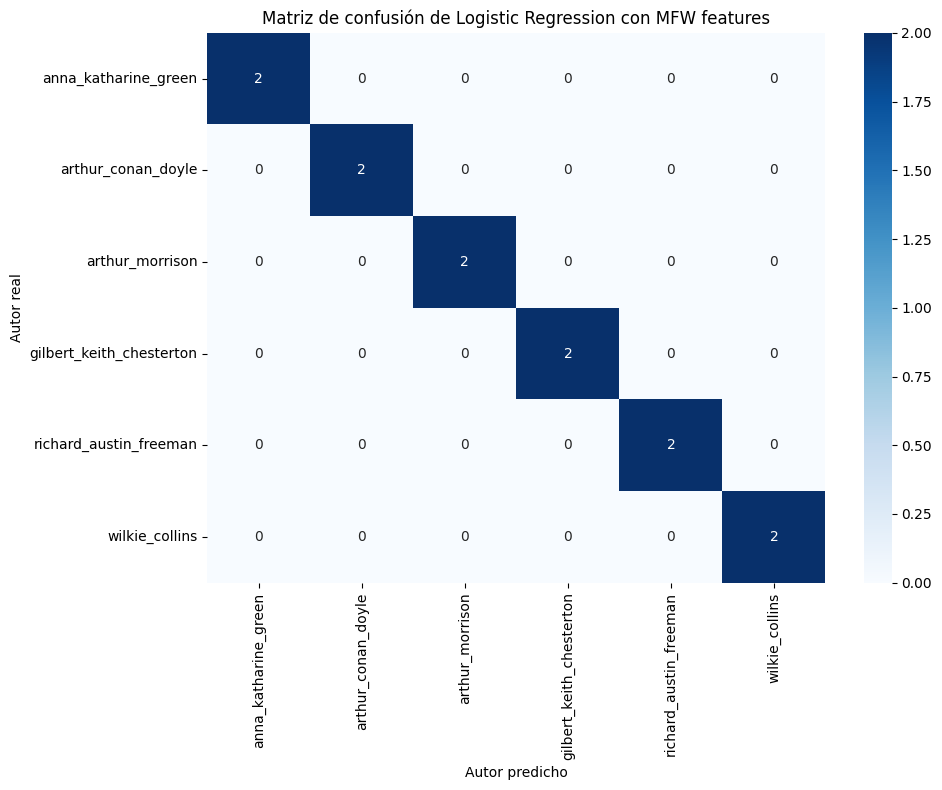

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
plot_confussion_matrix(cm=cm, labels=classes, model_name="Logistic Regression", features="MFW features")

In [10]:
proba_df = pd.DataFrame(y_proba, columns=classes, index=X_test.index)
ordered = np.sort(y_proba, axis=1)[:, ::-1]
second = ordered[:, 1] if y_proba.shape[1] > 1 else np.zeros(len(X_test))

confidence_df = pd.DataFrame(
    {
        "work": test_fw[title_col] if title_col else X_test.index.astype(str),
        "true_author": y_test.values,
        "pred_author": y_pred,
        "is_correct": y_test.values == y_pred,
        "proba_pred": ordered[:, 0],
        "proba_second": second,
        "margin": ordered[:, 0] - second,
    },
    index=X_test.index,
).sort_values("margin")

confidence_df

,work,true_author,pred_author,is_correct,proba_pred,proba_second,margin
5,am-the_hole_in_the_wall,arthur_morrison,arthur_morrison,True,0.688619,0.164522,0.524097
3,acd-the_lost_world,arthur_conan_doyle,arthur_conan_doyle,True,0.696186,0.171868,0.524317
8,raf-the_shadow_of_the_wolf,richard_austin_freeman,richard_austin_freeman,True,0.717890,0.187726,0.530163
9,raf-the_golden_pool,richard_austin_freeman,richard_austin_freeman,True,0.864449,0.052052,0.812397
2,acd-the_adventures_of_sherlock_holmes,arthur_conan_doyle,arthur_conan_doyle,True,0.895053,0.042499,0.852554
11,wc-armadale,wilkie_collins,wilkie_collins,True,0.934084,0.045042,0.889042
7,gkc-the_return_of_don_quixote,gilbert_keith_chesterton,gilbert_keith_chesterton,True,0.938163,0.022868,0.915295
10,wc-the_law_and_the_lady,wilkie_collins,wilkie_collins,True,0.971123,0.018240,0.952884
4,am-chronicles_of_martin_hewitt,arthur_morrison,arthur_morrison,True,0.971372,0.009528,0.961844
6,gkc-four_faultless_felons,gilbert_keith_chesterton,gilbert_keith_chesterton,True,0.976297,0.008280,0.968017


In [11]:
print("Casos ambiguos por menor margen:")
low_margin_cases = confidence_df.sort_values("margin").head()
low_margin_cases

Casos ambiguos por menor margen:


,work,true_author,pred_author,is_correct,proba_pred,proba_second,margin
5,am-the_hole_in_the_wall,arthur_morrison,arthur_morrison,True,0.688619,0.164522,0.524097
3,acd-the_lost_world,arthur_conan_doyle,arthur_conan_doyle,True,0.696186,0.171868,0.524317
8,raf-the_shadow_of_the_wolf,richard_austin_freeman,richard_austin_freeman,True,0.717890,0.187726,0.530163
9,raf-the_golden_pool,richard_austin_freeman,richard_austin_freeman,True,0.864449,0.052052,0.812397
2,acd-the_adventures_of_sherlock_holmes,arthur_conan_doyle,arthur_conan_doyle,True,0.895053,0.042499,0.852554


In [12]:
print("Aciertos de mayor confianza:")
high_confidence_correct_cases = (
    confidence_df[confidence_df["is_correct"]].sort_values("proba_pred", ascending=False).head()
)
high_confidence_correct_cases

Aciertos de mayor confianza:


,work,true_author,pred_author,is_correct,proba_pred,proba_second,margin
1,akg-to_the_minute,anna_katharine_green,anna_katharine_green,True,0.989547,0.006185,0.983362
0,akg-three_thousand_dollars,anna_katharine_green,anna_katharine_green,True,0.981753,0.006456,0.975297
6,gkc-four_faultless_felons,gilbert_keith_chesterton,gilbert_keith_chesterton,True,0.976297,0.008280,0.968017
4,am-chronicles_of_martin_hewitt,arthur_morrison,arthur_morrison,True,0.971372,0.009528,0.961844
10,wc-the_law_and_the_lady,wilkie_collins,wilkie_collins,True,0.971123,0.018240,0.952884


In [13]:
error_cases = confidence_df[~confidence_df["is_correct"]].sort_values("margin").head(10)

if not len(error_cases):
    print("No hay errores en el conjunto de test.")
else:
    print("Errores del modelo:")
    error_cases

No hay errores en el conjunto de test.


Los casos de margen bajo son los más útiles para investigar la ambigüedad de estilo. Los aciertos de alta confianza muestran patrones prototípicos y los errores permiten identificar las señales que empujan hacia un autor incorrecto.

## Cálculo de valores SHAP

Vamos a calcular los valores SHAP para el conjunto de test, lo que nos permitirá entender la contribución de cada palabra funcional a las predicciones del modelo.

Para ello, primero transformamos los datos de entrenamiento y prueba al espacio de características que el modelo utiliza internamente, lo que es necesario para calcular los valores SHAP correctamente.

In [14]:
# Transformamos los datos de entrenamiento y prueba
X_train_model_space = transformed_features(ml_pipeline, X_train, feature_cols)
X_test_model_space = transformed_features(ml_pipeline, X_test, feature_cols)

In [15]:
# Calculamos los valores SHAP para el conjunto de test
explainer = shap.LinearExplainer(clf, X_train_model_space)
shap_values = explainer(X_test_model_space)
values = shap_values.values
base_values = shap_values.base_values

print("X_train_model_space:", X_train_model_space.shape)
print("X_test_model_space:", X_test_model_space.shape)
print("SHAP values:", values.shape)
print("base_values:", np.shape(base_values))

X_train_model_space: (83, 25)
X_test_model_space: (12, 25)
SHAP values: (12, 25, 6)
base_values: (12, 6)


El cálculo de SHAP se realiza en el mismo espacio de variables que recibe el clasificador. Por eso se guardan dos valores: el valor transformado usado por el modelo y la frecuencia original, más útil para la lectura lingüística.

## Explicabilidad global por autor

In [16]:
global_shap_df = pd.concat(
    [top_shap_table_for_author(author, feature_cols, classes, values, top_n=len(feature_cols)) for author in classes],
    ignore_index=True,
)

top_global_by_author = (
    global_shap_df.sort_values(["author", "mean_abs_shap"], ascending=[True, False]).groupby("author").head(10)
)
top_global_by_author

,author,feature,word,mean_abs_shap,mean_shap,median_shap,share_positive,direction
0,anna_katharine_green,fw_but,but,0.540063,-0.182037,-0.140568,0.416667,pushes_away_from_author
1,anna_katharine_green,fw_not,not,0.332011,-0.174211,-0.258867,0.166667,pushes_away_from_author
2,anna_katharine_green,fw_of,of,0.323038,-0.059439,-0.070276,0.416667,pushes_away_from_author
3,anna_katharine_green,fw_the,the,0.306546,-0.094121,-0.119848,0.333333,pushes_away_from_author
4,anna_katharine_green,fw_it,it,0.286341,-0.050380,-0.073397,0.416667,pushes_away_from_author
5,anna_katharine_green,fw_is,is,0.260199,0.129153,0.130074,0.833333,pushes_toward_author
6,anna_katharine_green,fw_at,at,0.244191,-0.080562,-0.072768,0.416667,pushes_away_from_author
7,anna_katharine_green,fw_to,to,0.243319,-0.046720,-0.123030,0.333333,pushes_away_from_author
8,anna_katharine_green,fw_she,she,0.212395,-0.028116,-0.082868,0.333333,pushes_away_from_author
9,anna_katharine_green,fw_her,her,0.195820,-0.065120,-0.151360,0.333333,pushes_away_from_author


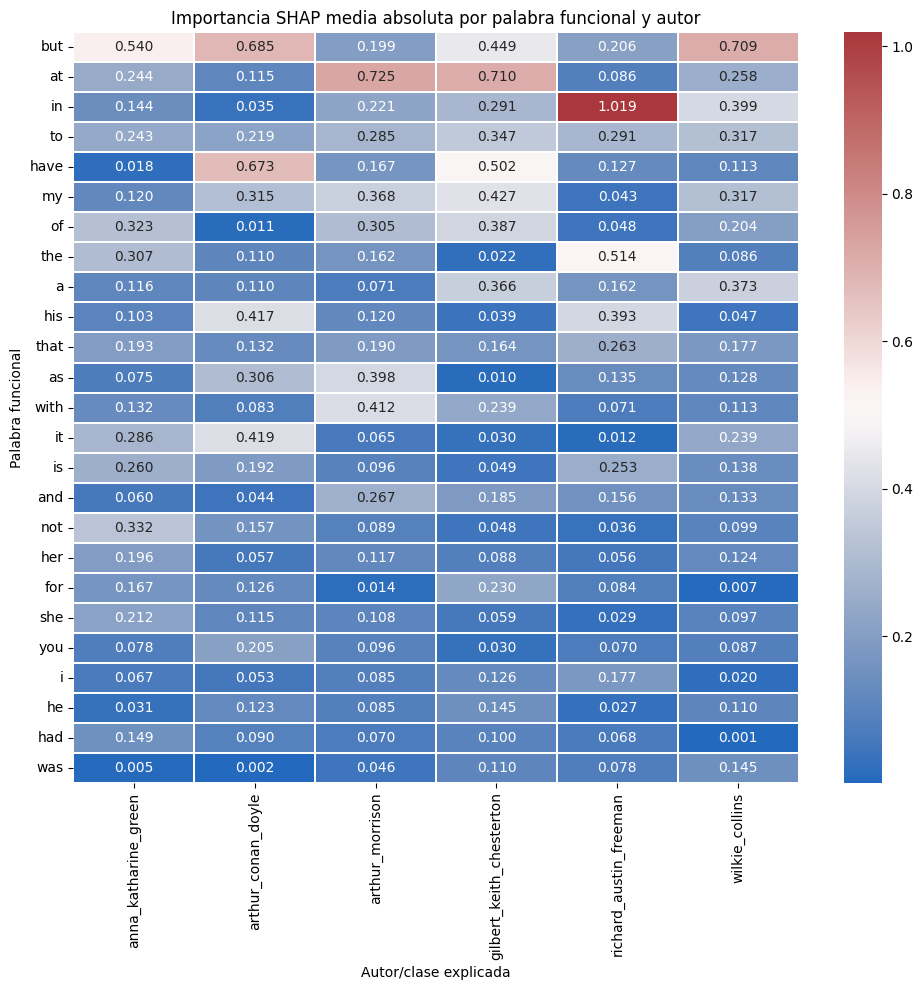

In [17]:
heatmap_df = global_shap_df.pivot(index="word", columns="author", values="mean_abs_shap")
heatmap_df = heatmap_df.loc[heatmap_df.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 10))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="vlag", linewidths=0.1)
plt.title("Importancia SHAP media absoluta por palabra funcional y autor")
plt.xlabel("Autor/clase explicada")
plt.ylabel("Palabra funcional")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS_DIR / "mfw_lr_shap_global_heatmap_by_author.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
classes

['anna_katharine_green',
 'arthur_conan_doyle',
 'arthur_morrison',
 'gilbert_keith_chesterton',
 'richard_austin_freeman',
 'wilkie_collins']

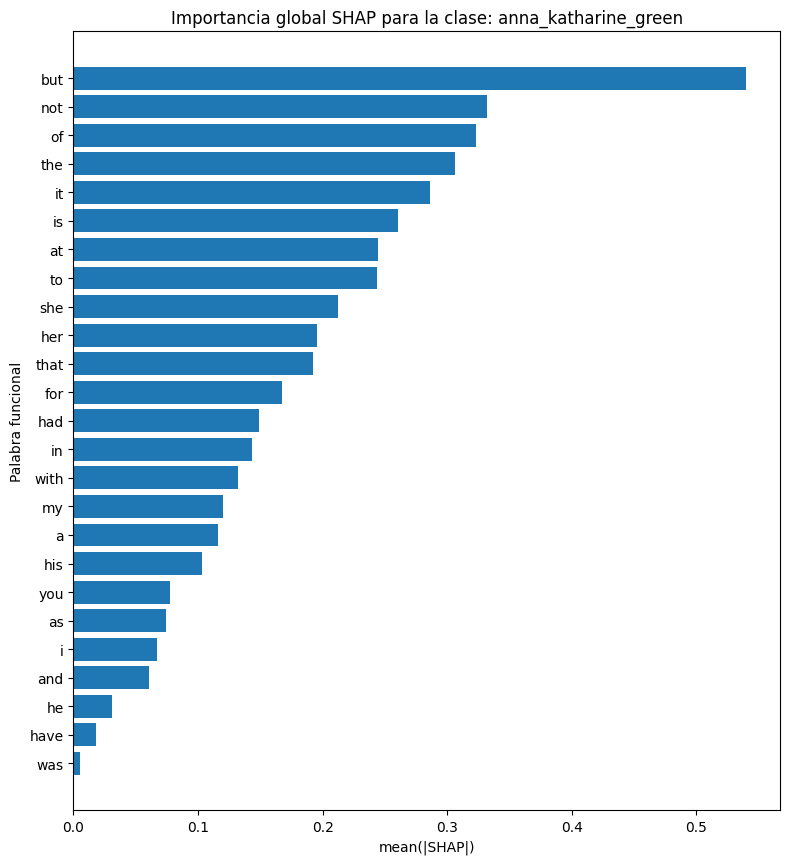

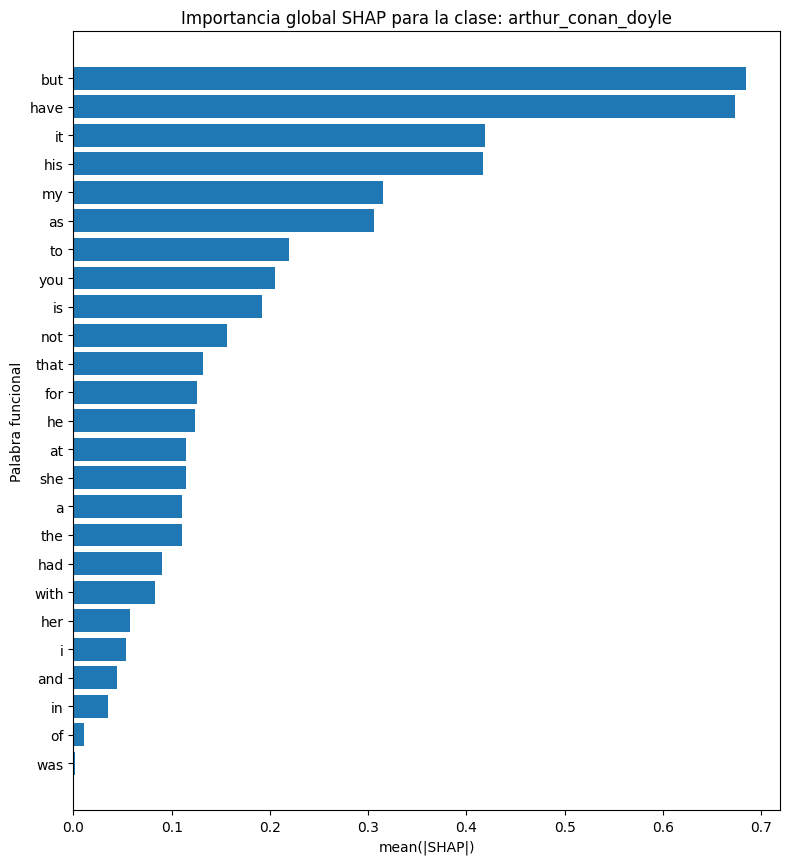

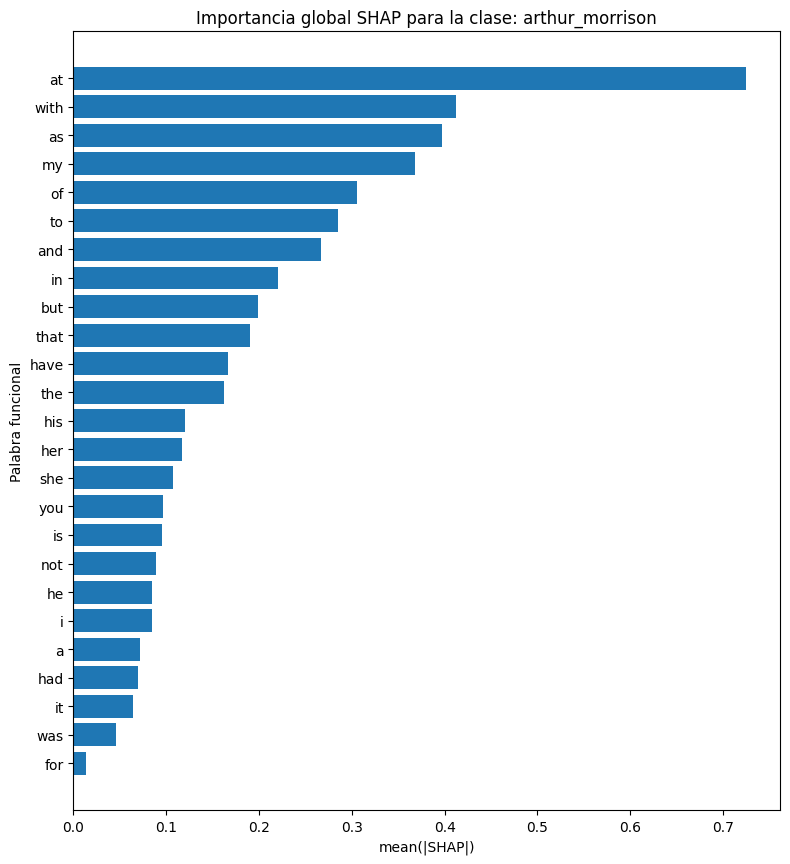

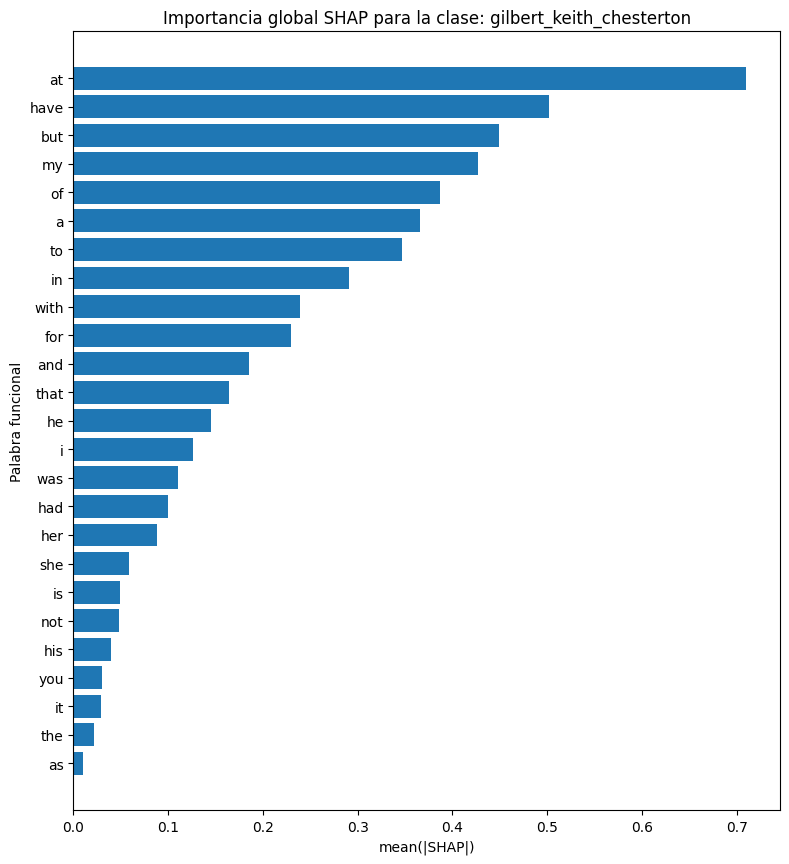

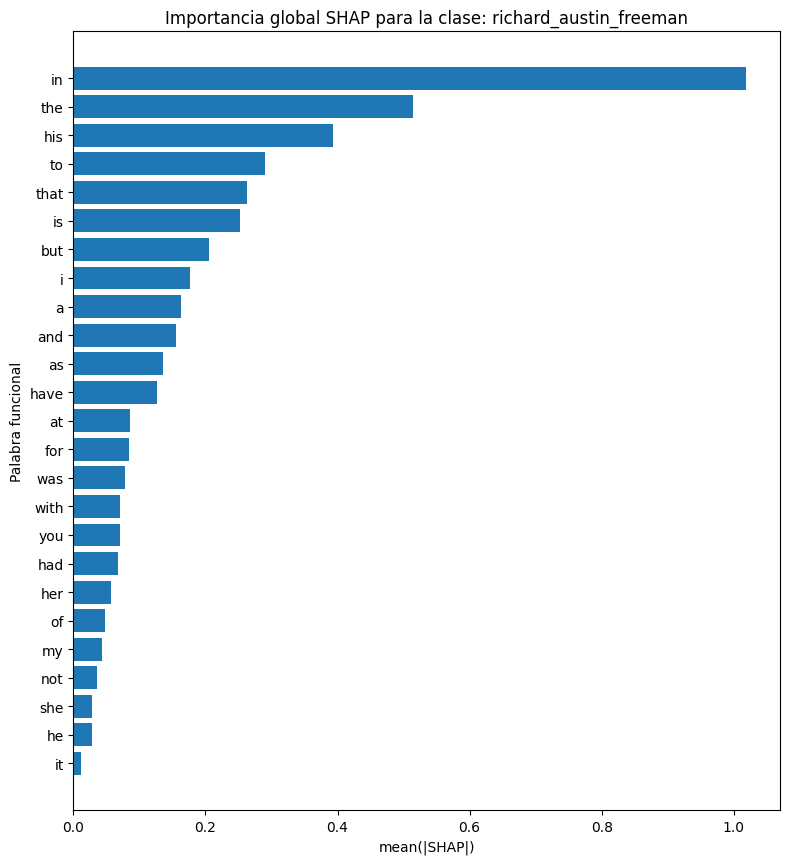

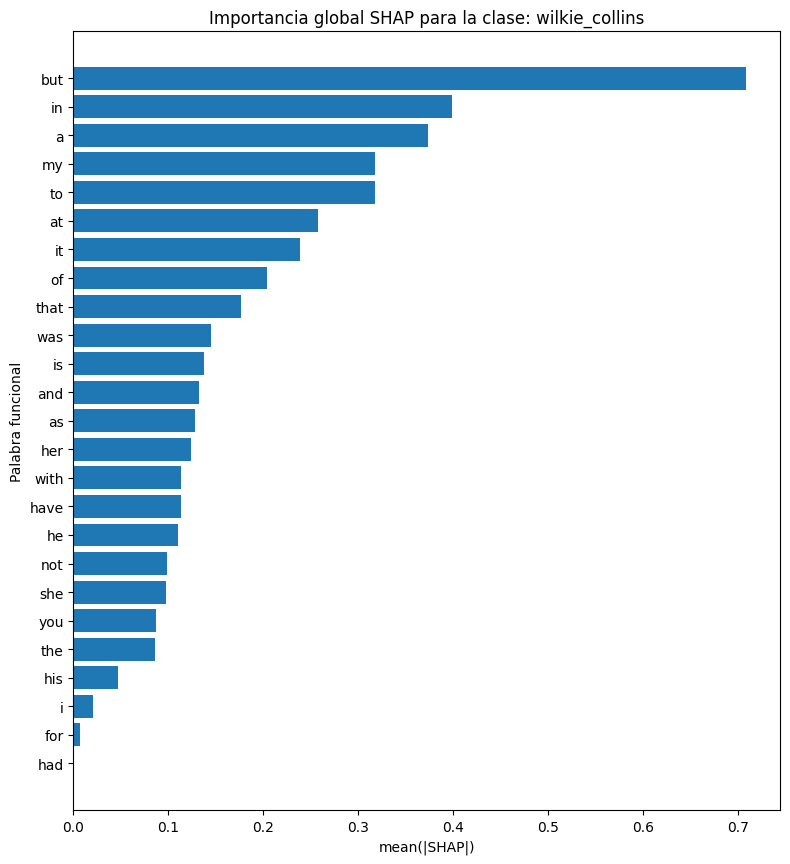

In [19]:
for author in classes:
    df_ = top_shap_table_for_author(author, feature_cols, classes, values, top_n=len(feature_cols))
    plot_global_bar_for_author(df_, author, FIGS_DIR / f"mfw_lr_shap_global_bar_{author}.png")

### Beeswarm por autor
El beeswarm complementa las barras porque muestra simultáneamente magnitud, signo y valor de la palabra funcional. Es el gráfico más útil para ver si una frecuencia alta o baja de una palabra empuja hacia un autor.

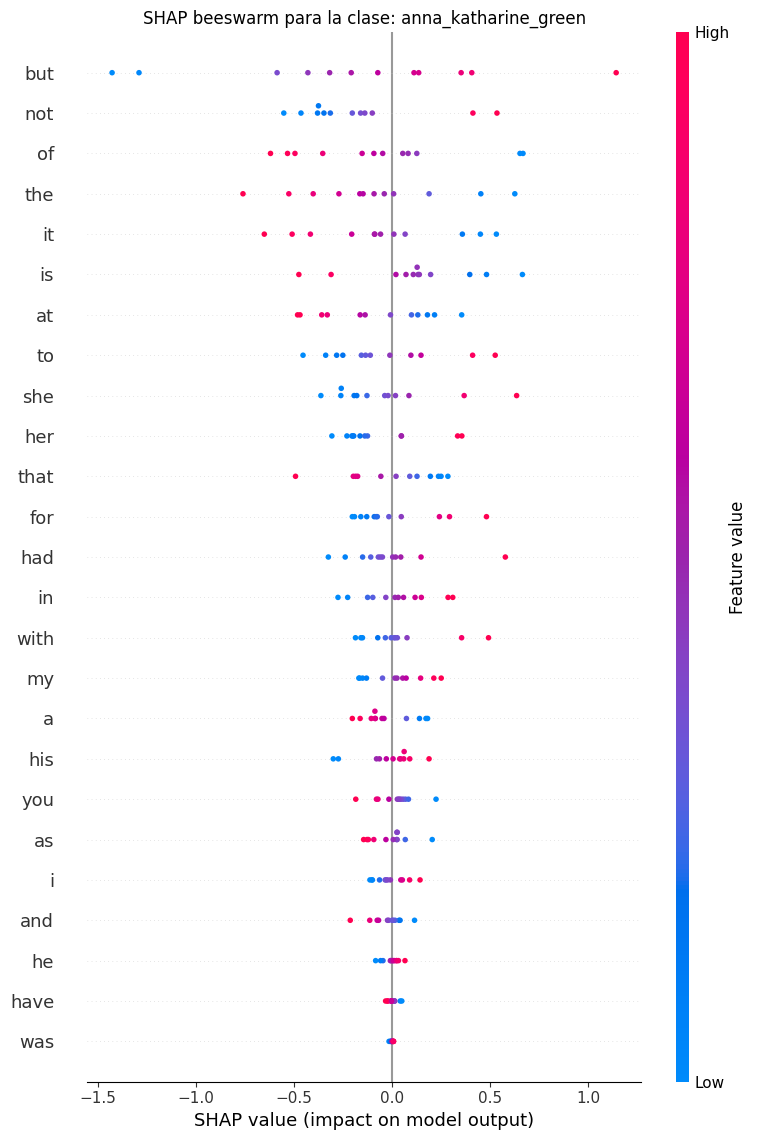

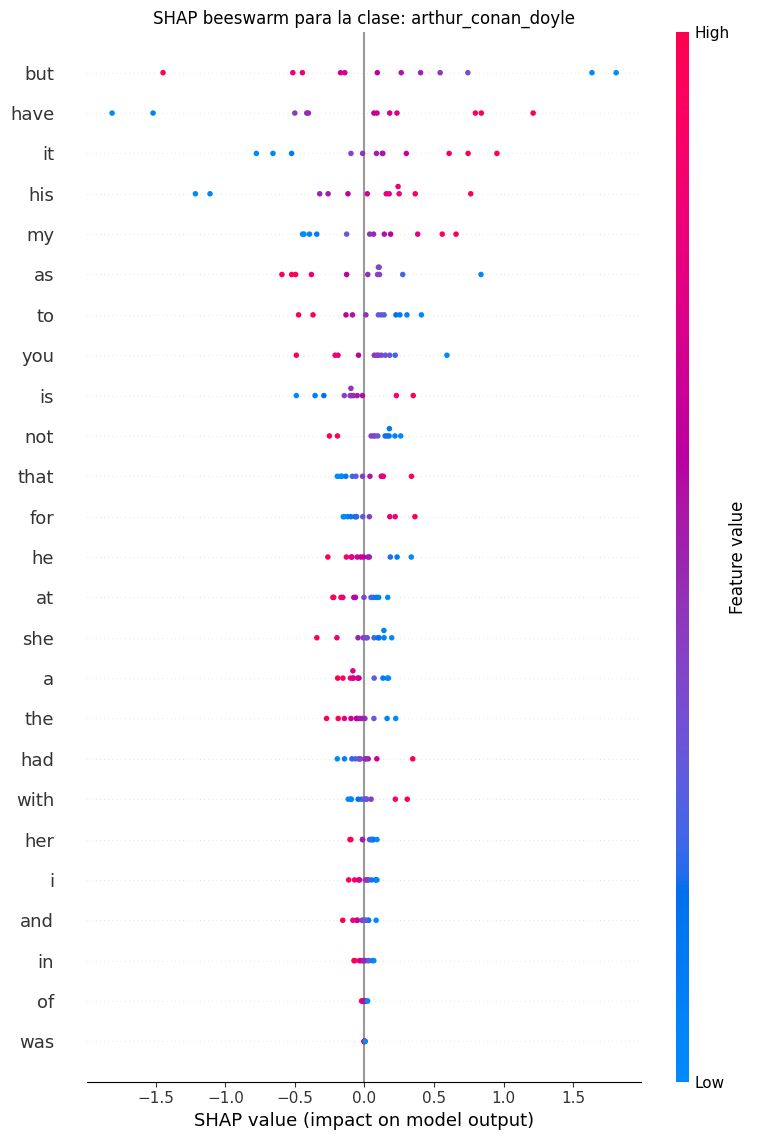

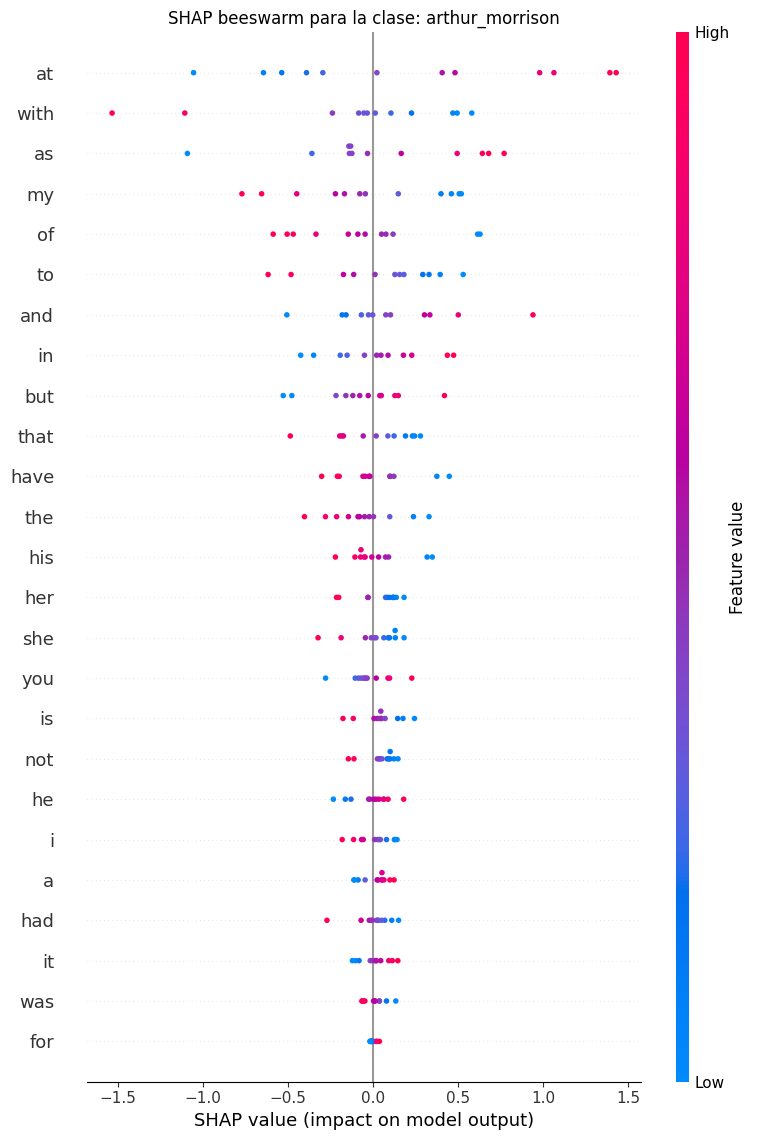

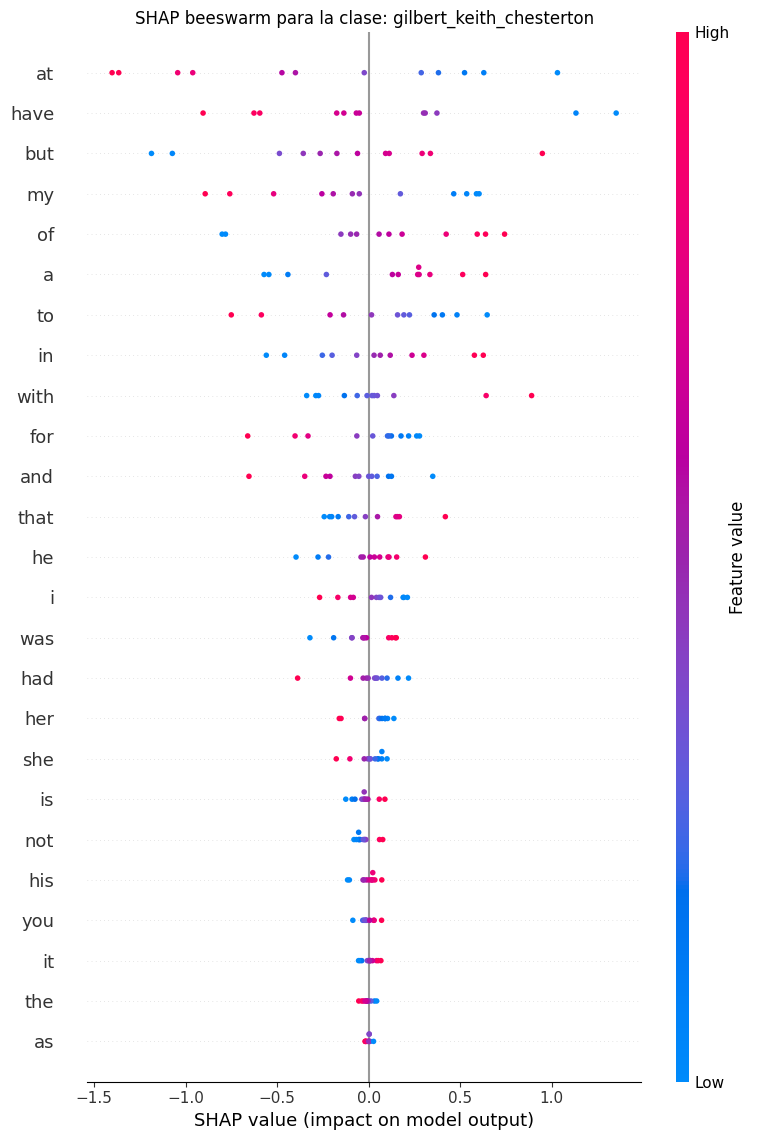

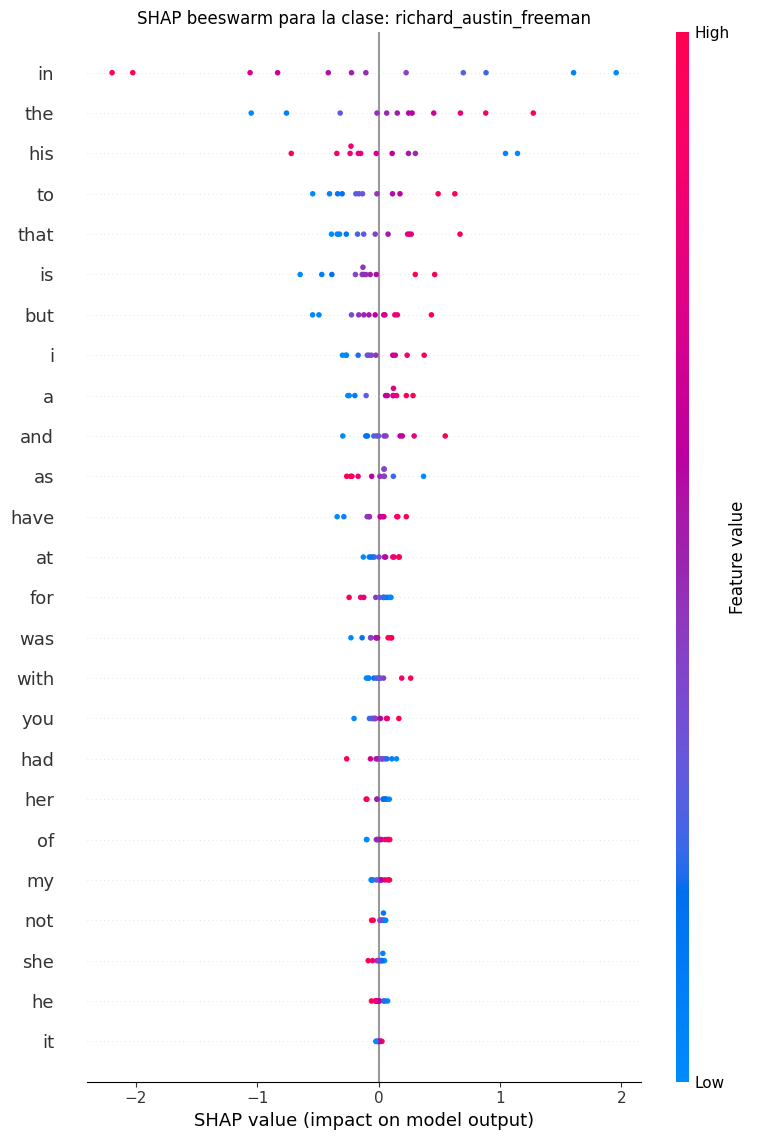

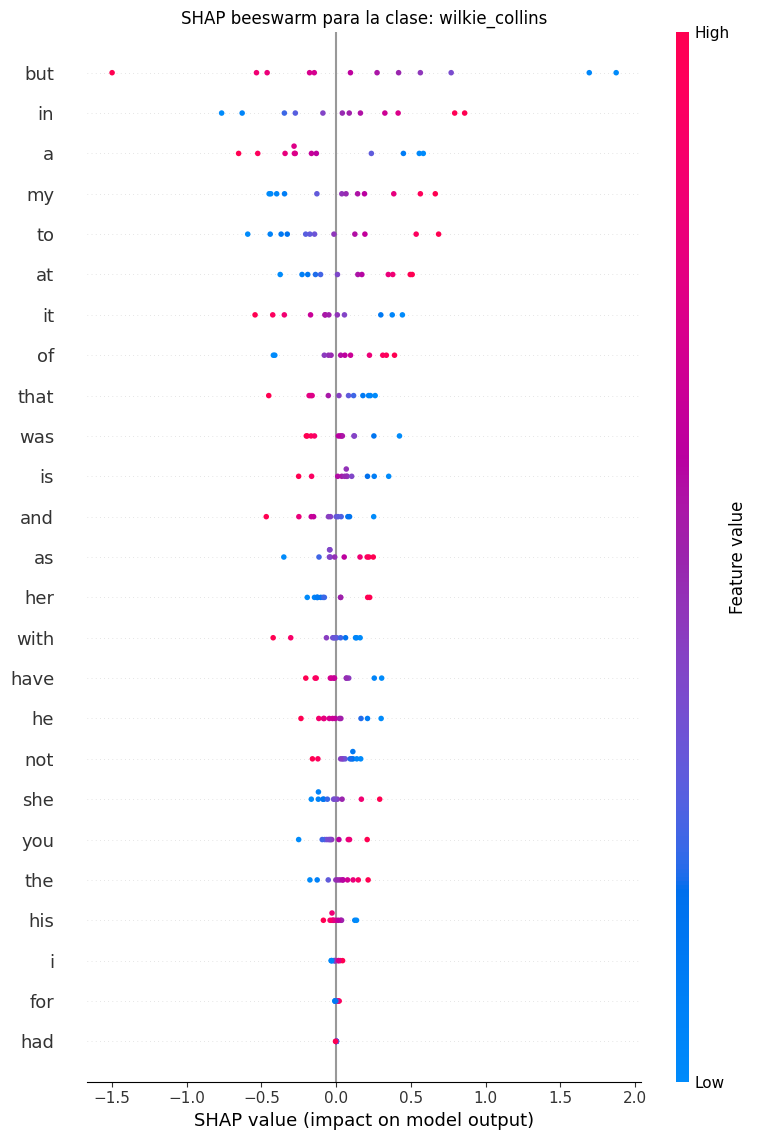

In [20]:
for author in classes:
    mat = shap_matrix_for_author(author, classes, values)
    exp = shap.Explanation(
        values=mat,
        base_values=np.repeat(base_value_for_author(author, classes, base_values), len(X_test_model_space)),
        data=X_test_model_space[feature_cols].values,
        feature_names=[clean_feature_name(c) for c in feature_cols],
    )
    plot_beeswarm_for_author(author, exp, FIGS_DIR / f"mfw_lr_shap_beeswarm_{author}.png")

## Comparación entre coeficientes y SHAP

In [21]:
coef_df = pd.DataFrame(clf.coef_, index=classes, columns=feature_cols)
coef_long = coef_df.reset_index(names="author").melt(id_vars="author", var_name="feature", value_name="coef")
coef_long["word"] = coef_long["feature"].map(clean_feature_name)
coef_long["abs_coef"] = coef_long["coef"].abs()

coef_shap_comparison = global_shap_df.merge(coef_long, on=["author", "feature", "word"], how="left")
coef_shap_comparison.to_csv(TABLES_DIR / "mfw_lr_coef_vs_shap_by_author.csv", index=False)
display(
    coef_shap_comparison.sort_values(["author", "mean_abs_shap"], ascending=[True, False]).groupby("author").head(10)
)

,author,feature,word,mean_abs_shap,mean_shap,median_shap,share_positive,direction,coef,abs_coef
0,anna_katharine_green,fw_but,but,0.540063,-0.182037,-0.140568,0.416667,pushes_away_from_author,0.608602,0.608602
1,anna_katharine_green,fw_not,not,0.332011,-0.174211,-0.258867,0.166667,pushes_away_from_author,0.679110,0.679110
2,anna_katharine_green,fw_of,of,0.323038,-0.059439,-0.070276,0.416667,pushes_away_from_author,-0.290333,0.290333
3,anna_katharine_green,fw_the,the,0.306546,-0.094121,-0.119848,0.333333,pushes_away_from_author,-0.531082,0.531082
4,anna_katharine_green,fw_it,it,0.286341,-0.050380,-0.073397,0.416667,pushes_away_from_author,-0.456197,0.456197
5,anna_katharine_green,fw_is,is,0.260199,0.129153,0.130074,0.833333,pushes_toward_author,-0.410868,0.410868
6,anna_katharine_green,fw_at,at,0.244191,-0.080562,-0.072768,0.416667,pushes_away_from_author,-0.329046,0.329046
7,anna_katharine_green,fw_to,to,0.243319,-0.046720,-0.123030,0.333333,pushes_away_from_author,0.405142,0.405142
8,anna_katharine_green,fw_she,she,0.212395,-0.028116,-0.082868,0.333333,pushes_away_from_author,0.504062,0.504062
9,anna_katharine_green,fw_her,her,0.195820,-0.065120,-0.151360,0.333333,pushes_away_from_author,0.479945,0.479945


Los coeficientes muestran la dirección aprendida por el modelo; SHAP pondera esa dirección por los valores reales observados en las obras. Una palabra con coeficiente alto puede ser poco relevante globalmente si apenas varía en el test.

## Explicabilidad local de obras concretas

ACIERTO MUY SEGURO
Instancia seleccionada: 0

Explicación local de `akg-three_thousand_dollars`
- Autor real: `anna_katharine_green`
- Autor predicho: `anna_katharine_green`
- Clase explicada: `anna_katharine_green`
- Probabilidad de la predicción: `0.981753`
- Probabilidad de la clase explicada: `0.981753`
- Probabilidad de la segunda clase más probable: `0.006456`
- Margen de confianza: `0.975297`
- Es correcta la predicción: Sí


,feature,word,feature_value_model_space,original_feature_value,shap_value,abs_shap_value,effect
19,fw_but,but,1.639853,0.011912,1.142451,1.142451,a favor
3,fw_of,of,-2.279743,0.018357,0.667384,0.667384,a favor
22,fw_she,she,1.398725,0.015175,0.634940,0.634940,a favor
23,fw_not,not,0.948968,0.010280,0.534727,0.534727,a favor
0,fw_the,the,-0.724264,0.048544,0.452382,0.452382,a favor
15,fw_her,her,0.982610,0.014767,0.355726,0.355726,a favor
16,fw_as,as,-1.626160,0.006445,0.204633,0.204633,a favor
11,fw_you,you,2.085588,0.018194,-0.185175,0.185175,en contra
5,fw_a,a,-0.754497,0.018683,0.139705,0.139705,a favor
2,fw_to,to,-0.443913,0.024313,-0.135113,0.135113,en contra


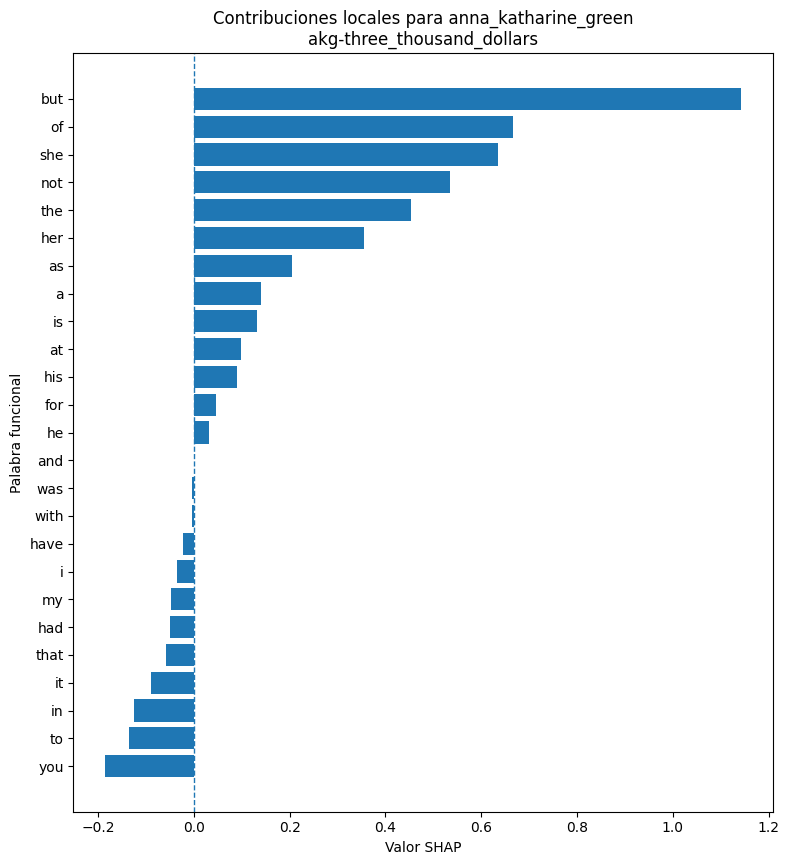

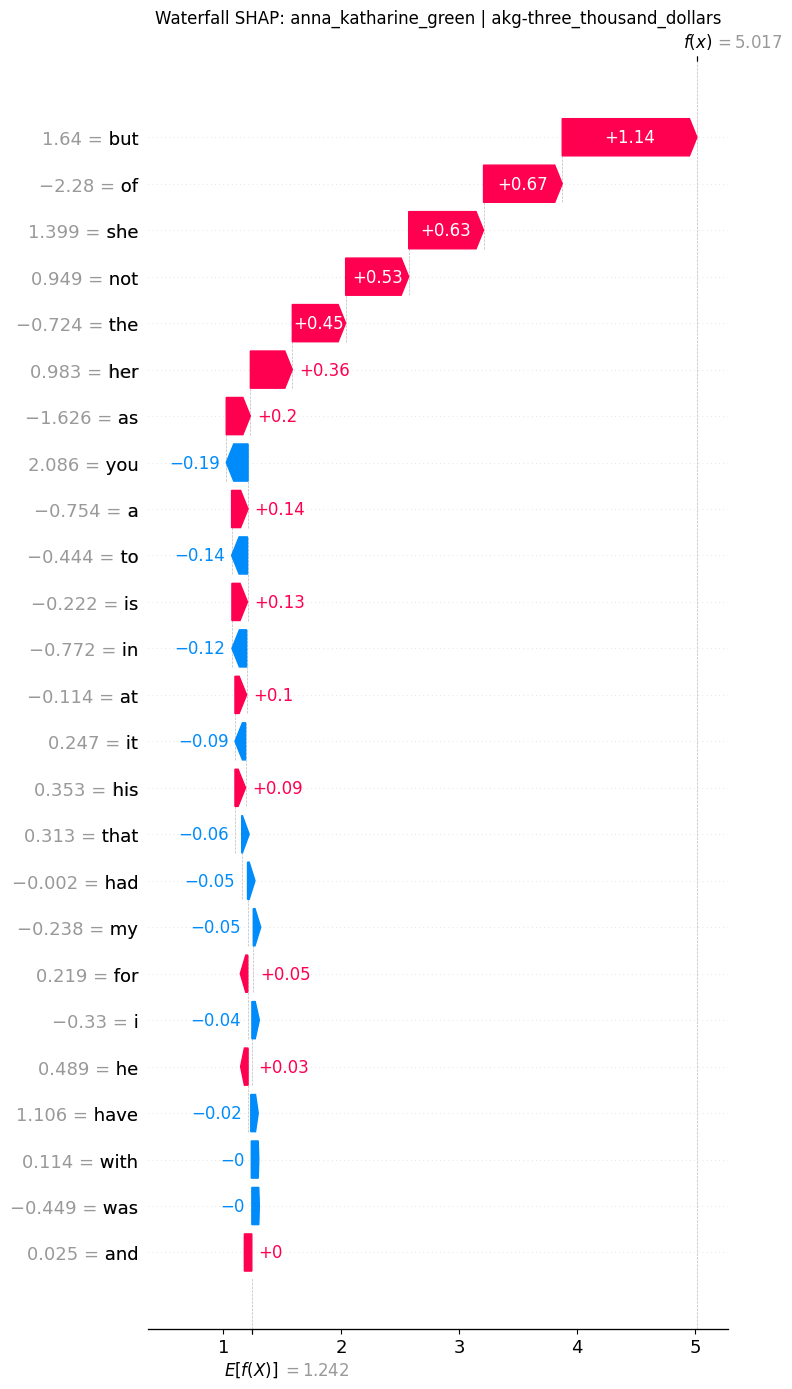

Lectura local:
- Señales a favor de `anna_katharine_green`: but, of, she, not, the. 
- Señales en contra: you, to, in, it, that.


In [22]:
print("ACIERTO MUY SEGURO")
hc_index = high_confidence_correct_cases.sample(random_state=SEED).index
print(f"Instancia seleccionada: {hc_index[0]}\n")
local_explanation(
    hc_index[0],
    confidence_df,
    proba_df,
    X_test,
    X_test_model_space,
    classes,
    values,
    base_values,
    FIGS_DIR,
    feature_cols,
)

ACIERTO MUY SEGURO
Instancia seleccionada: 0

Explicación local de `akg-three_thousand_dollars`
- Autor real: `anna_katharine_green`
- Autor predicho: `anna_katharine_green`
- Clase explicada: `anna_katharine_green`
- Probabilidad de la predicción: `0.981753`
- Probabilidad de la clase explicada: `0.981753`
- Probabilidad de la segunda clase más probable: `0.006456`
- Margen de confianza: `0.975297`
- Es correcta la predicción: Sí


,feature,word,feature_value_model_space,original_feature_value,shap_value,abs_shap_value,effect
19,fw_but,but,1.639853,0.011912,1.142451,1.142451,a favor
3,fw_of,of,-2.279743,0.018357,0.667384,0.667384,a favor
22,fw_she,she,1.398725,0.015175,0.634940,0.634940,a favor
23,fw_not,not,0.948968,0.010280,0.534727,0.534727,a favor
0,fw_the,the,-0.724264,0.048544,0.452382,0.452382,a favor
15,fw_her,her,0.982610,0.014767,0.355726,0.355726,a favor
16,fw_as,as,-1.626160,0.006445,0.204633,0.204633,a favor
11,fw_you,you,2.085588,0.018194,-0.185175,0.185175,en contra
5,fw_a,a,-0.754497,0.018683,0.139705,0.139705,a favor
2,fw_to,to,-0.443913,0.024313,-0.135113,0.135113,en contra


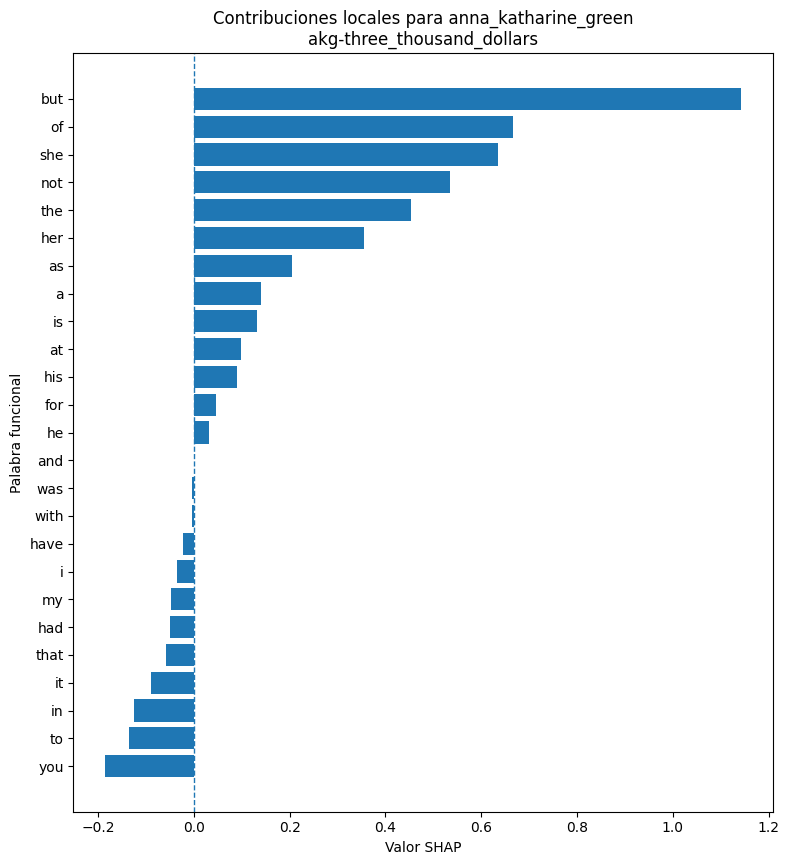

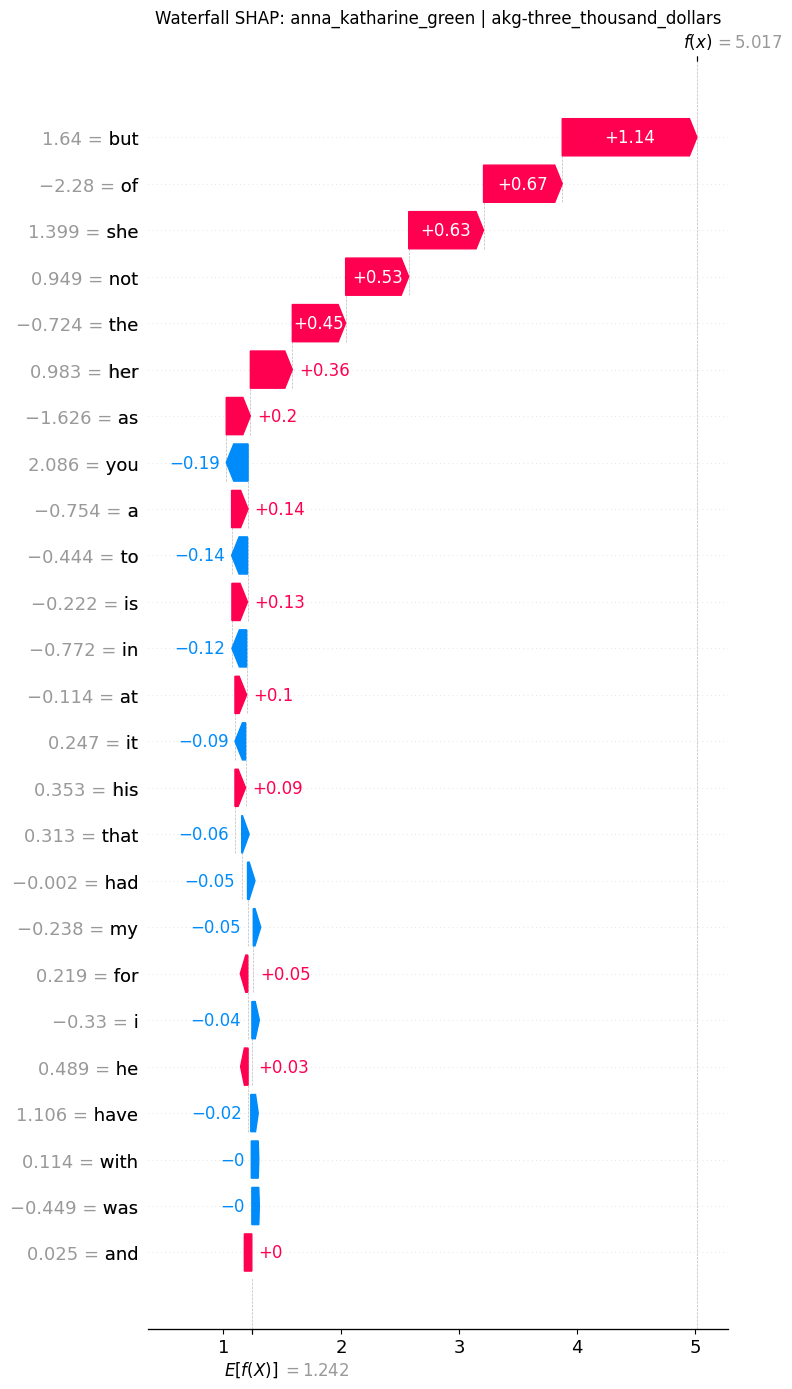

Lectura local:
- Señales a favor de `anna_katharine_green`: but, of, she, not, the. 
- Señales en contra: you, to, in, it, that.


In [23]:
print("ACIERTO MUY SEGURO")
hc_index = high_confidence_correct_cases.sample(random_state=SEED).index
print(f"Instancia seleccionada: {hc_index[0]}\n")
local_explanation(
    hc_index[0],
    confidence_df,
    proba_df,
    X_test,
    X_test_model_space,
    classes,
    values,
    base_values,
    FIGS_DIR,
    feature_cols,
)

ACIERTO AMBIGUO
Instancia seleccionada: 3
Explicación local de `acd-the_lost_world`
- Autor real: `arthur_conan_doyle`
- Autor predicho: `arthur_conan_doyle`
- Clase explicada: `arthur_conan_doyle`
- Probabilidad de la predicción: `0.696186`
- Probabilidad de la clase explicada: `0.696186`
- Probabilidad de la segunda clase más probable: `0.171868`
- Margen de confianza: `0.524317`
- Es correcta la predicción: Sí


,feature,word,feature_value_model_space,original_feature_value,shap_value,abs_shap_value,effect
19,fw_but,but,-1.200571,0.005619,0.743355,0.743355,a favor
10,fw_it,it,0.962732,0.015784,0.609005,0.609005,a favor
12,fw_his,his,-0.423506,0.008637,-0.322077,0.322077,en contra
8,fw_he,he,-0.942862,0.009107,0.234481,0.234481,a favor
2,fw_to,to,-0.730174,0.022644,0.226386,0.226386,a favor
11,fw_you,you,-0.921309,0.008428,0.220834,0.220834,a favor
22,fw_she,she,-0.580986,0.000627,0.195776,0.195776,a favor
24,fw_have,have,0.223959,0.006599,0.181239,0.181239,a favor
23,fw_not,not,-0.397955,0.004534,0.179239,0.179239,a favor
18,fw_for,for,-0.573688,0.006455,-0.144443,0.144443,en contra


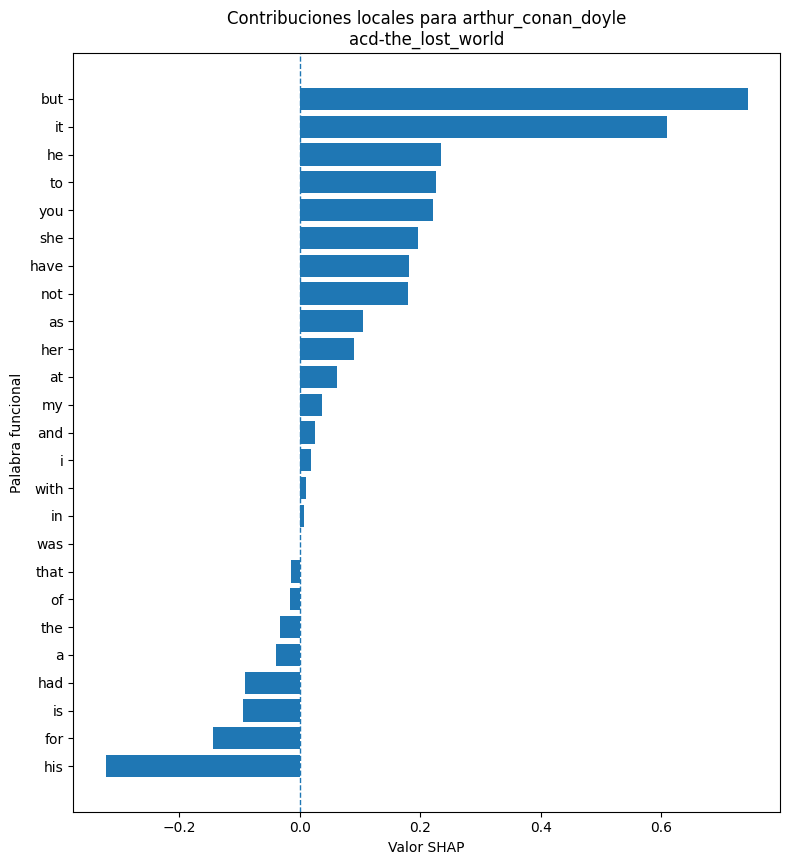

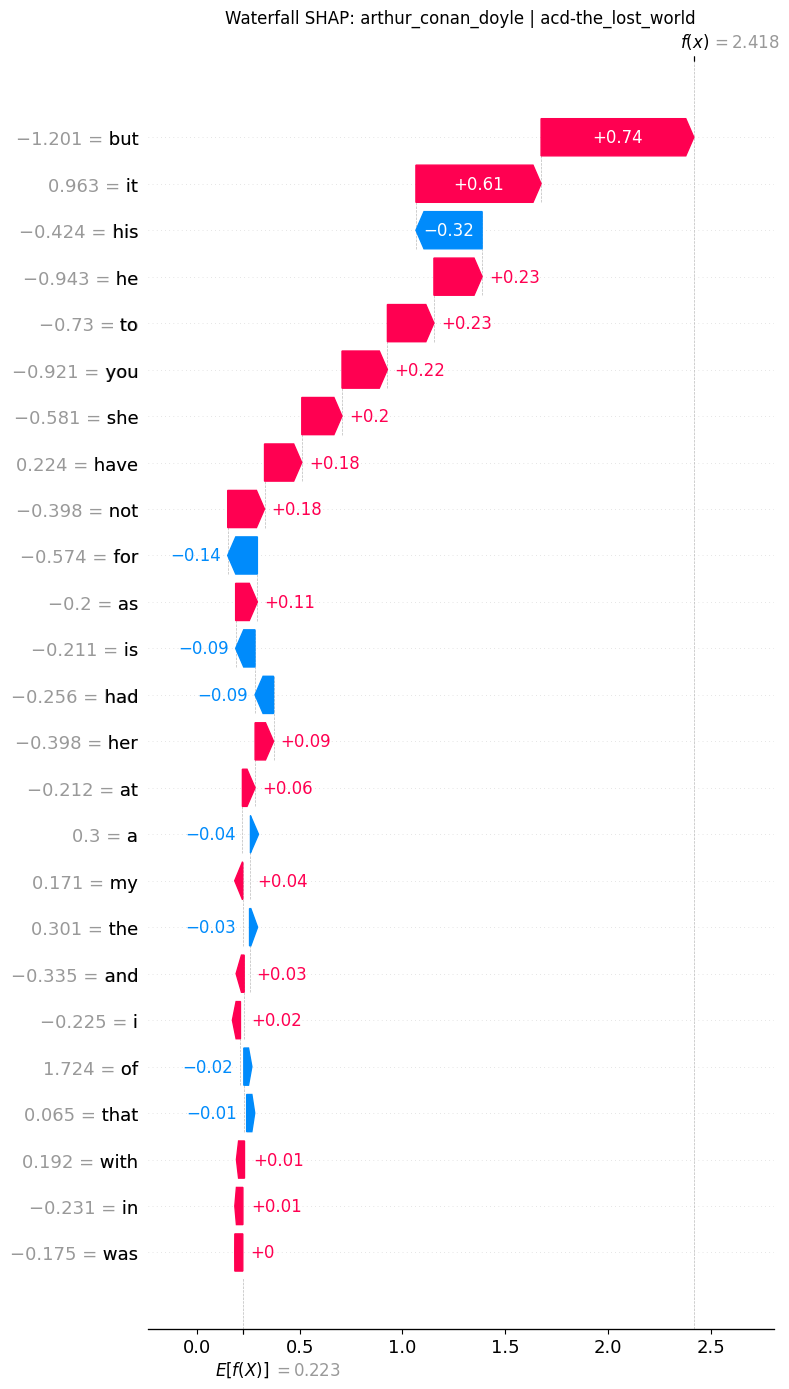

Lectura local:
- Señales a favor de `arthur_conan_doyle`: but, it, he, to, you. 
- Señales en contra: his, for, is, had, a.


In [24]:
print("ACIERTO AMBIGUO")
lm_index = low_margin_cases.sample(random_state=SEED).index
print(f"Instancia seleccionada: {lm_index[0]}")
local_explanation(
    lm_index[0],
    confidence_df,
    proba_df,
    X_test,
    X_test_model_space,
    classes,
    values,
    base_values,
    FIGS_DIR,
    feature_cols,
)

Para una obra concreta, la explicación más completa compara la clase predicha y, si difiere, la clase verdadera. En una obra mal clasificada, las palabras con SHAP positivo hacia el autor incorrecto suelen revelar la fuente de la confusión.

## Decision plot, force plot y dependence plots

In [25]:
instance_id = low_margin_cases.sample(random_state=SEED).index[0]
selected_author = confidence_df.loc[instance_id, "pred_author"]
row_pos = X_test.index.get_loc(instance_id)
mat = shap_matrix_for_author(selected_author, classes, values)
base_value = base_value_for_author(selected_author, classes, base_values, row_pos)

print("Obra seleccionada:", confidence_df.loc[instance_id, "work"])
print("Autor real:", confidence_df.loc[instance_id, "true_author"])
print("Autor predicho:", confidence_df.loc[instance_id, "pred_author"])
print("Clase explicada:", selected_author)

Obra seleccionada: acd-the_lost_world
Autor real: arthur_conan_doyle
Autor predicho: arthur_conan_doyle
Clase explicada: arthur_conan_doyle


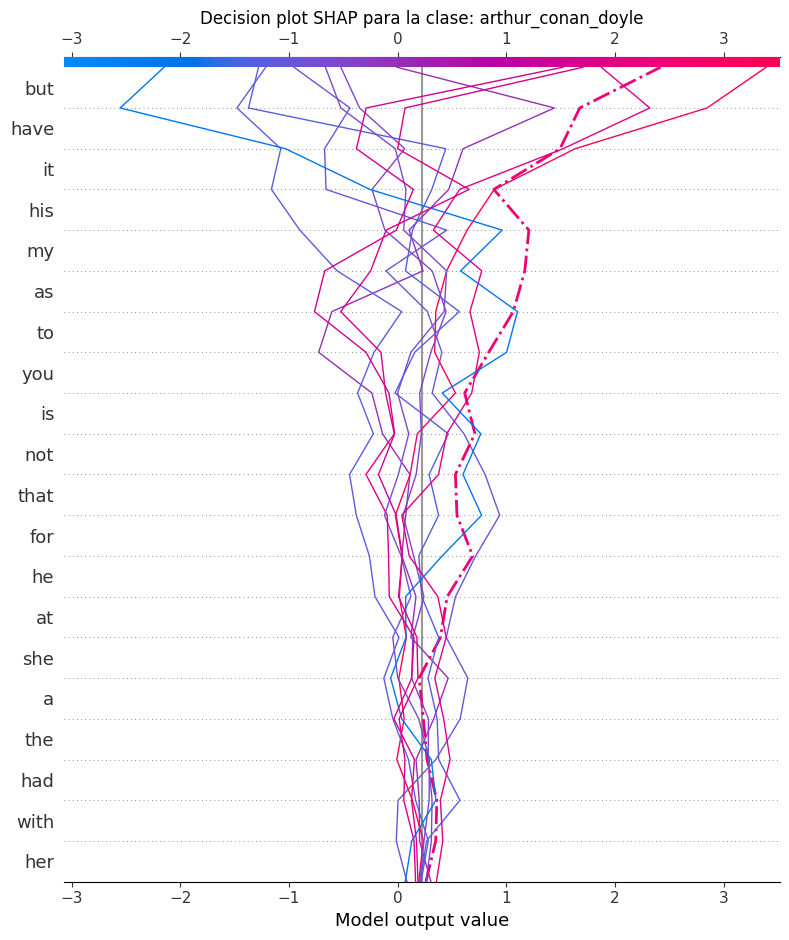

In [26]:
plot_shap_decision(base_value, mat, X_test_model_space, feature_cols, row_pos, selected_author, instance_id, FIGS_DIR)

In [27]:
plot_shap_force(
    base_value,
    mat,
    row_pos,
    X_test_model_space,
    instance_id,
    feature_cols,
)

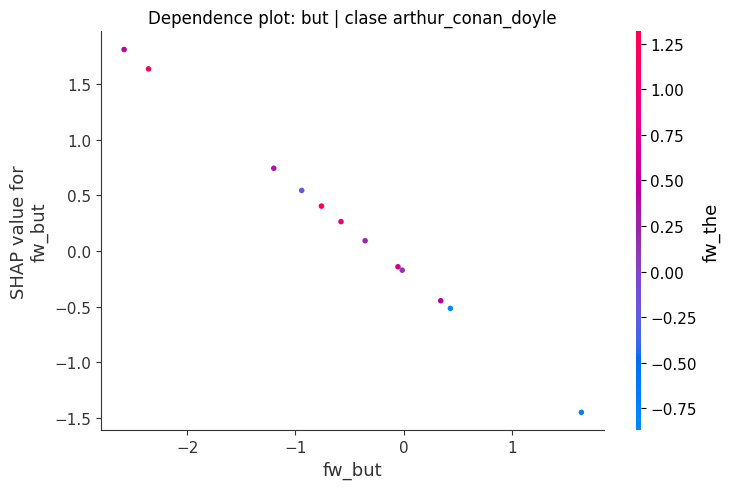

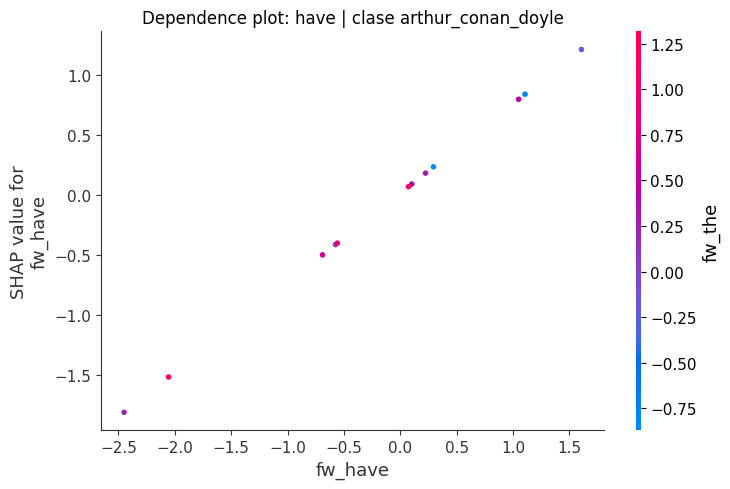

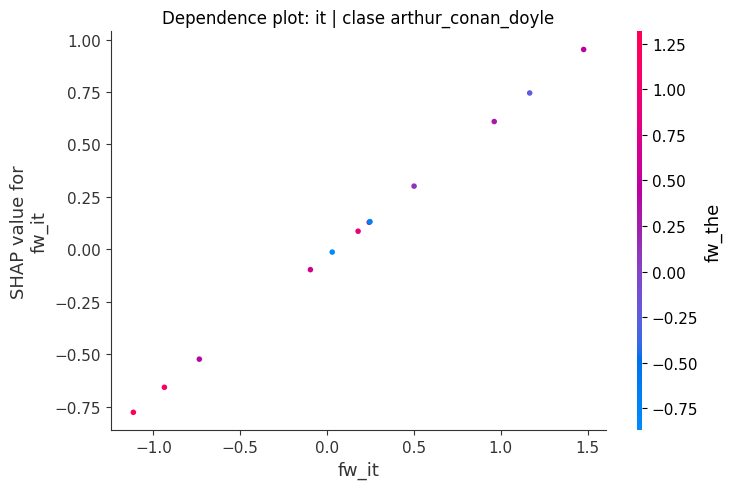

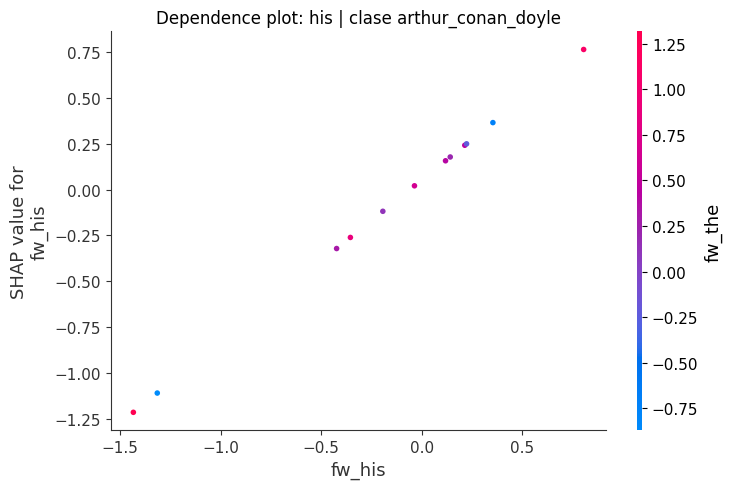

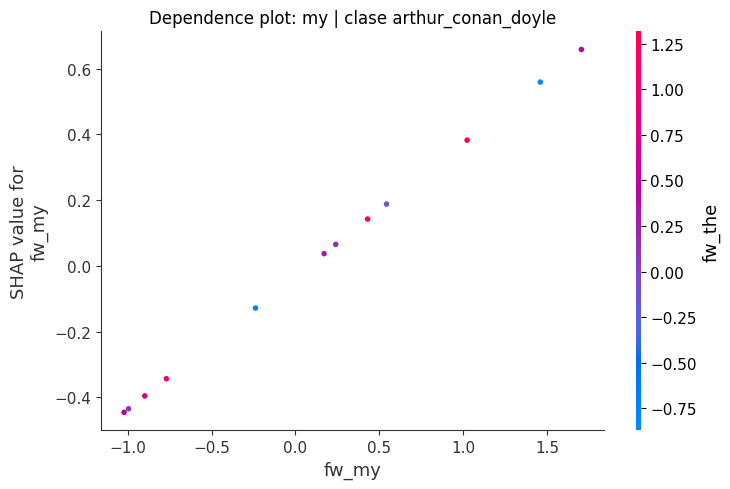

In [28]:
top_table = top_shap_table_for_author(selected_author, feature_cols, classes, values, top_n=5)
plot_dependence_for_top_features(selected_author, mat, X_test_model_space, top_table, feature_cols, FIGS_DIR)

El `decision_plot` muestra la trayectoria acumulada desde el valor base hasta la salida final. El `force_plot` es útil para una lectura interactiva de una única obra. Los dependence plots permiten ver si una palabra funcional empuja más hacia un autor cuando su frecuencia es alta o baja.